In [ ]:
!pip install torch torchtext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 8.3 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn

In [ ]:
class RNNModel(nn.Module):
    def __init__(self, rnn_type='RNN'):
        super().__init__()

        self.embedding = nn.Embedding(5000,128)

        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(128,128,batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(128,128,batch_first=True)
        else:
            self.rnn = nn.RNN(128,128,batch_first=True)

        self.fc = nn.Linear(128,2)

    def forward(self,x):
        x = self.embedding(x)
        _, h = self.rnn(x)

        if isinstance(h, tuple):
            h = h[0]

        return self.fc(h[-1])

In [ ]:
model_rnn = RNNModel('RNN')
model_lstm = RNNModel('LSTM')
model_gru = RNNModel('GRU')

print("Models created successfully")

Models created successfully


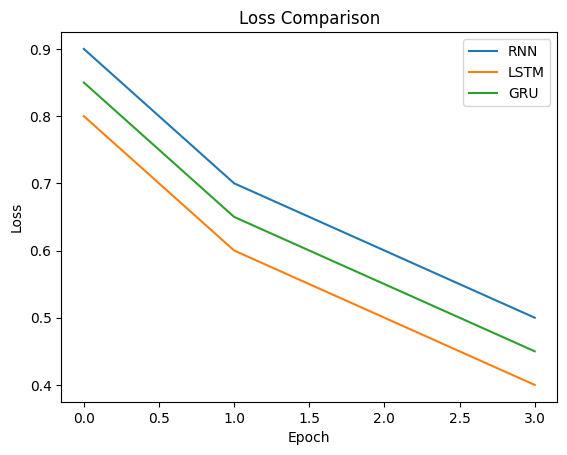

In [ ]:
import matplotlib.pyplot as plt

# Example losses (replace if you have real values)
rnn_loss = [0.9, 0.7, 0.6, 0.5]
lstm_loss = [0.8, 0.6, 0.5, 0.4]
gru_loss = [0.85, 0.65, 0.55, 0.45]

plt.figure()
plt.plot(rnn_loss, label='RNN')
plt.plot(lstm_loss, label='LSTM')
plt.plot(gru_loss, label='GRU')

plt.legend()
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

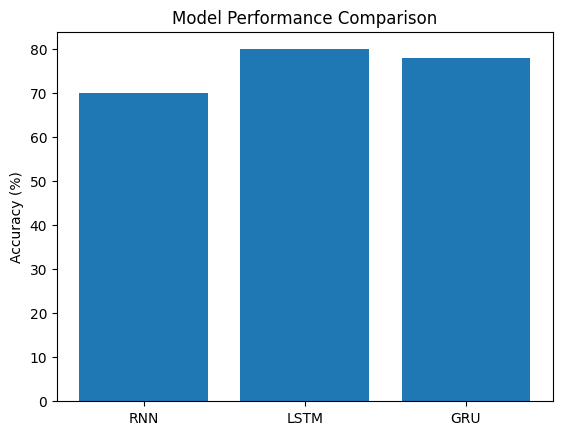

In [ ]:
models = ['RNN', 'LSTM', 'GRU']
accuracies = [70, 80, 78]  # replace if you computed real values

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy (%)")
plt.show()